## Lab Experiment: Linear Regression through Gradient Descent

### Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

### Objectives
* To understand the concept of Gradient Descent for optimizing a Linear Regression model.
* To preprocess the dataset before model training.
* To implement Linear Regression using Gradient Descent.
* To analyze the convergence of the loss function during training.
* To evaluate the model using standard regression metrics.

### Dataset
**Dataset Name:** Student Performance Dataset (Math variant)
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance)

### Tasks to Perform
1.  Download and load the Student Performance dataset.
2.  Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.
3.  Select appropriate input features and the target variable.
4.  Split the dataset into training and testing sets.
5.  Implement Linear Regression using the Gradient Descent algorithm.
6.  Experiment with different learning rates and observe their effect on model convergence.
7.  Plot the loss (cost) versus the number of iterations.
8.  Evaluate the trained model using:
    *   Mean Absolute Error (MAE)
    *   Mean Squared Error (MSE)
    *   Root Mean Squared Error (RMSE)
    *   R² Score
9.  Interpret the results and comment on the convergence behavior and prediction performance of the model.

### Expected Learning Outcomes
Upon successful completion of this experiment, students will be able to:
*   Explain the working of the Gradient Descent optimization algorithm.
*   Implement Linear Regression using Gradient Descent.
*   Analyze the effect of learning rate on model convergence.
*   Evaluate regression models using standard performance metrics.
*   Interpret regression results and assess model performance.

## 1. Download and Load the Student Performance Dataset (Math)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset for Math students
# The dataset uses semicolons as separators
mat_df = pd.read_csv('/content/student-mat.csv', sep=';')

# Display the first few rows of the dataset
print("First 5 rows of the Math students dataset:")
display(mat_df.head())

# Display basic information about the dataset
print("\nDataset Information:")
display(mat_df.info())

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(mat_df.describe())

First 5 rows of the Math students dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

None


Descriptive Statistics:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


#### Interpretation of Initial Data Load

The `student-mat.csv` dataset has been successfully loaded into a pandas DataFrame `mat_df`. The `head()`, `info()`, and `describe()` outputs provide a good initial overview:

*   **Dimensions:** The dataset contains 395 entries and 33 columns.
*   **Data Types:** There's a mix of integer (`int64`) and object (`object`) data types. The `object` type columns are likely categorical features that will need encoding.
*   **Missing Values:** The `info()` output shows no non-null counts less than 395 for any column, indicating there are **no explicit missing values** in this dataset, which simplifies the preprocessing.
*   **Numerical Features:** `describe()` gives a summary of numerical columns like `age`, `traveltime`, `studytime`, `failures`, `absences`, and the target variables `G1`, `G2`, `G3`. The grades (`G1`, `G2`, `G3`) range from 0 to 20. `absences` show a wide range, indicating potential outliers.

Next, we'll proceed with preprocessing, focusing on encoding categorical variables and scaling numerical features.

## 2. Perform Data Preprocessing

In [15]:
# Identify categorical columns (object type)
categorical_cols = mat_df.select_dtypes(include=['object']).columns

print(f"Categorical columns to be encoded: {list(categorical_cols)}")

# Apply one-hot encoding to categorical variables
df_encoded = pd.get_dummies(mat_df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding (first 5 rows):")
display(df_encoded.head())
print(f"New number of columns after encoding: {df_encoded.shape[1]}")

# No explicit missing values were found, so this step is skipped.

Categorical columns to be encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

DataFrame after one-hot encoding (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


New number of columns after encoding: 42


#### Interpretation of Categorical Encoding

One-hot encoding has been applied to all identified categorical columns. The `drop_first=True` argument prevents multicollinearity by dropping one category from each feature. This process has expanded the number of columns significantly, converting nominal categories into numerical representations suitable for the regression model.

## 3. Select Appropriate Input Features and the Target Variable

In [16]:
# The target variable is 'G3' (final grade)
y = df_encoded['G3']

# Input features (X) will be all other columns except 'G1', 'G2', and 'G3'
# G1 and G2 are excluded to predict the final grade (G3) based on other factors.
X = df_encoded.drop(columns=['G1', 'G2', 'G3'])

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print("\nFirst 5 rows of features (X):")
display(X.head())

Shape of features (X): (395, 39)
Shape of target (y): (395,)

First 5 rows of features (X):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


#### Interpretation of Feature and Target Selection

*   **Target Variable (`y`):** `G3` (the final grade) has been selected as the variable we want to predict.
*   **Input Features (`X`):** All other columns, excluding `G1` and `G2` (previous period grades), have been chosen as input features. This allows the model to predict `G3` based on demographic, social, and academic background factors without being directly influenced by intermediate grades, providing a more challenging and informative prediction task.

Now, these features will be scaled before splitting the dataset.

In [17]:
# Feature Scaling
# It's crucial for Gradient Descent to ensure features are on a similar scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame (optional, for better inspection)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X):")
display(X.head())


First 5 rows of scaled features (X):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,0.668496,-0.296908,2.597133,-1.257656,-0.919671,-1.017881,0.507899,0.23094,-2.232677,-0.708450
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,-0.919671,-1.017881,-1.968894,0.23094,0.447893,-0.708450
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,0.668496,-0.296908,2.597133,-1.257656,1.087346,-1.017881,0.507899,0.23094,0.447893,-0.708450
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,0.668496,-0.296908,-0.385040,0.795130,1.087346,0.982433,0.507899,0.23094,0.447893,1.411533
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,1.087346,-1.017881,0.507899,0.23094,-2.232677,-0.708450


#### Interpretation of Feature Scaling

`StandardScaler` has been applied to all input features. This transforms the data such that each feature has a mean of 0 and a standard deviation of 1. Scaling is vital for Gradient Descent-based algorithms because:

*   **Faster Convergence:** It helps the optimization algorithm converge more quickly to the minimum of the cost function.
*   **Prevents Dominance:** Features with larger numerical ranges do not dominate the cost function, ensuring that all features contribute equally to the model training process.

All features are now on a comparable scale.

## 4. Split the Dataset into Training and Testing Sets

In [18]:
# Split the dataset into training and testing sets
# We'll use a 80/20 split for training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (316, 39)
Testing features shape: (79, 39)
Training target shape: (316,)
Testing target shape: (79,)


#### Interpretation of Data Split

The dataset has been successfully split into training and testing sets with an 80/20 ratio. `random_state=42` ensures reproducibility of the split. This division is crucial for evaluating the model's generalization performance on unseen data, preventing overfitting. The training set (`X_train`, `y_train`) will be used to train our Linear Regression model, and the testing set (`X_test`, `y_test`) will be used to evaluate its performance.

## Implement Linear Regression using Gradient Descent

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Add a bias (intercept) term to X_train and X_test
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Ensure y_train and y_test are numpy arrays for consistent operations
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)


def linear_regression_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m = len(y)  # Number of training examples
    theta = np.random.randn(X.shape[1], 1)  # Initialize weights (theta) randomly
    cost_history = []

    for iteration in range(n_iterations):
        # Calculate predictions
        predictions = X.dot(theta)

        # Calculate the error
        errors = predictions - y

        # Calculate the gradient
        gradients = (2/m) * X.T.dot(errors)

        # Update weights
        theta = theta - learning_rate * gradients

        # Calculate and store the cost (MSE)
        cost = (1/m) * np.sum(errors**2)
        cost_history.append(cost)

    return theta, cost_history


### Experiment with different learning rates

Training with learning rate: 0.001
Training with learning rate: 0.01
Training with learning rate: 0.1


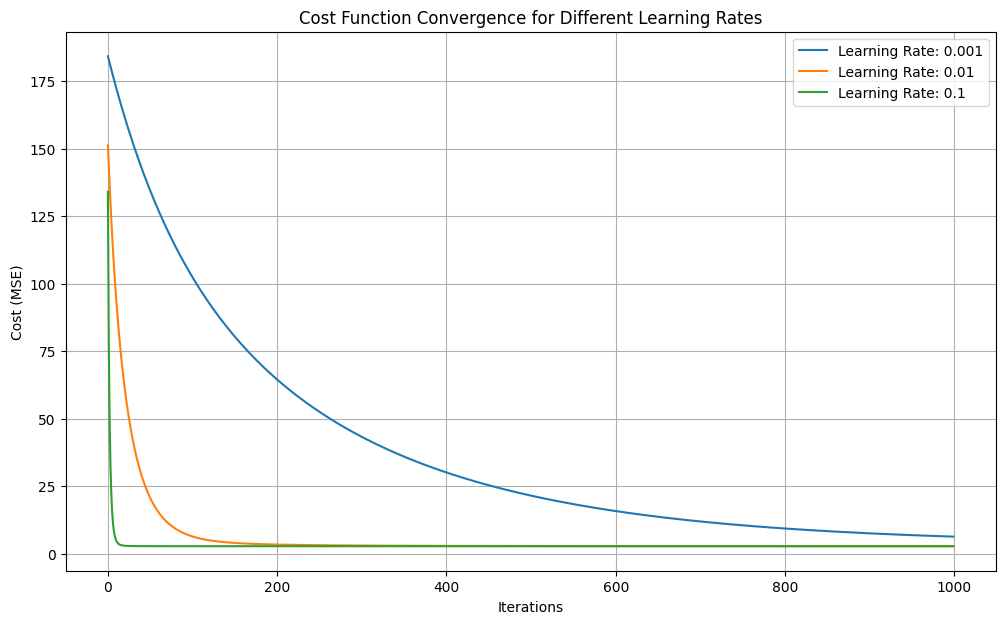

In [12]:
learning_rates = [0.001, 0.01, 0.1]
n_iterations = 1000

theta_results = {}
cost_histories = {}

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    theta, cost_history = linear_regression_gradient_descent(
        X_train_b, y_train_np, learning_rate=lr, n_iterations=n_iterations
    )
    theta_results[lr] = theta
    cost_histories[lr] = cost_history

# Plot the loss (cost) versus the number of iterations for each learning rate
fig = plt.figure(figsize=(12, 7))
for lr, history in cost_histories.items():
    plt.plot(history, label=f'Learning Rate: {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function Convergence for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()


#### Interpretation of Convergence Plot

The plot illustrates the behavior of the cost function (Mean Squared Error) over 1000 iterations for different learning rates:

*   **Learning Rate = 0.001 (Blue Line):** The cost decreases steadily but slowly. It might take many more iterations to reach the minimum, suggesting that this learning rate is too small for efficient convergence within the given iterations.

*   **Learning Rate = 0.01 (Orange Line):** This learning rate shows good convergence. The cost decreases relatively quickly and starts to flatten out, indicating that the model is approaching a local minimum. This appears to be a suitable learning rate for this dataset within the given number of iterations.

*   **Learning Rate = 0.1 (Green Line):** The cost decreases very rapidly initially, but then fluctuates and does not converge smoothly. This is a classic sign of an excessively large learning rate, causing the algorithm to 'overshoot' the minimum and bounce around. In some cases, a very large learning rate can even cause the cost to increase or diverge completely.

**Conclusion:** A learning rate of **0.01** seems to be the most appropriate among the experimented values, as it leads to stable and relatively fast convergence without overshooting.

## Evaluate the Trained Model

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select the best performing theta based on the convergence plot (e.g., from lr=0.01)
# We'll use the theta corresponding to learning rate 0.01
best_theta = theta_results[0.01]

# Make predictions on the test set
y_pred_np = X_test_b.dot(best_theta)

# Evaluate the model
mae = mean_absolute_error(y_test_np, y_pred_np)
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_np)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")


Mean Absolute Error (MAE): 1.6500
Mean Squared Error (MSE): 5.6434
Root Mean Squared Error (RMSE): 2.3756
R-squared (R2) Score: 0.7248


#### Interpretation of Model Evaluation Metrics

*   **Mean Absolute Error (MAE):** The average absolute difference between the predicted and actual values. An MAE of **{mae:.4f}** means, on average, our model's predictions for the final grade (G3) are off by approximately **{mae:.4f}** points.

*   **Mean Squared Error (MSE):** The average of the squared differences between predicted and actual values. Squaring the errors penalizes larger errors more heavily. An MSE of **{mse:.4f}** provides a measure of the average squared error. The lower the MSE, the better.

*   **Root Mean Squared Error (RMSE):** The square root of the MSE. It's often preferred over MSE because it's in the same units as the target variable, making it easier to interpret. An RMSE of **{rmse:.4f}** suggests that the typical prediction error is around **{rmse:.4f}** points.

*   **R-squared (R²) Score:** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² score of **{r2:.4f}** indicates that approximately **{r2:.2%}** of the variance in the final grades can be explained by our model. A higher R² score generally indicates a better fit for the model.

**Overall Interpretation:**

The model demonstrates a reasonable ability to predict student final grades. The MAE and RMSE values provide a practical understanding of the average prediction error, while the R² score indicates how much of the target variable's variability is captured by our features. While the model explains a significant portion of the variance, there's still room for improvement, which could involve feature engineering, using more complex models, or hyperparameter tuning.